In [125]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from config import BCI2A_PATH, MI_DATA_PATH, LOW_FREQ, HIGH_FREQ, SAMPLING_RATE, BCI_MAPPING
from autoreject import AutoReject
LOW_FREQ = 1
HIGH_FREQ = 40
SAMPLING_RATE = 250

In [126]:
ch_names = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
    'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
    'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
    'P1', 'Pz', 'P2',
    'POz',
    'EOG-left', 'EOG-central', 'EOG-right'
]

In [127]:
def load_data(path, channels = ['C3', 'C4', 'Cz'], format = '.gdf', sampling_rate = SAMPLING_RATE, low_freq = LOW_FREQ, high_freq = HIGH_FREQ, mapping = None, transform = None):
    parent_dir = os.path.dirname(path)
    raw_files = [os.path.join(parent_dir, f) for f in os.listdir(parent_dir) if f.endswith(format)]
    print(f"Found {len(raw_files)} raw data files in {path}.")
    raw_data = []
    for file in raw_files:
        raw = mne.io.read_raw_gdf(file, preload=True)

        if raw.info['sfreq'] != sampling_rate:
            raw.resample(sampling_rate)

        if transform is not None:
            raw.rename_channels(lambda x: transform(x))        

        if mapping is not None:
            raw.rename_channels(mapping)

        raw.set_channel_types({
            'EOG-left': 'eog',
            'EOG-central': 'eog',
            'EOG-right': 'eog'
        })

        raw.set_montage('standard_1020')

        if channels is not None:
            raw.pick_channels(channels)

        raw.filter(low_freq, high_freq)

        raw_data.append(raw)
    return raw_data    

In [128]:
def bci2a_transform(channel_name):
    return channel_name.replace('EEG-', '')

In [129]:
training_bci = load_data(
    path = BCI2A_PATH,
    transform = bci2a_transform,
    mapping = BCI_MAPPING,
    channels=None,
    # channels = ['C3', 'C4', 'Cz', 'FC3', 'FC4', 'CP3', 'CP4'],
    low_freq=LOW_FREQ, 
    high_freq=HIGH_FREQ, 
    format = 'T.gdf')


evaluation_bci = load_data(
    path = BCI2A_PATH,
    transform = bci2a_transform,
    mapping = BCI_MAPPING,
    channels=None,
    # channels = ['C3', 'C4', 'Cz', 'FC3', 'FC4', 'CP3', 'CP4'],
    low_freq=LOW_FREQ,
    high_freq=HIGH_FREQ,
    format = 'E.gdf')

Found 9 raw data files in ./data/BCI-2A/.
Extracting GDF parameters from ./data/BCI-2A\A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Users\Madhav\AppData\Roaming\uv\python\cpython-3.13.7-windows-x86_64-none\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Extracting GDF parameters from ./data/BCI-2A\A02T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 677168  =      0.000 ...  2708.672 secs...


C:\Users\Madhav\AppData\Roaming\uv\python\cpython-3.13.7-windows-x86_64-none\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Extracting GDF parameters from ./data/BCI-2A\A03T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 660529  =      0.000 ...  2642.116 secs...


...

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Extracting GDF parameters from ./data/BCI-2A\A08E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 687791  =      0.000 ...  2751.164 secs...


C:\Users\Madhav\AppData\Roaming\uv\python\cpython-3.13.7-windows-x86_64-none\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Extracting GDF parameters from ./data/BCI-2A\A09E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 675097  =      0.000 ...  2700.388 secs...


C:\Users\Madhav\AppData\Roaming\uv\python\cpython-3.13.7-windows-x86_64-none\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)



In [80]:
print(f"Loaded Training BCI2A data: {len(training_bci)} files")
print(f"Loaded Evaluation BCI2A data: {len(evaluation_bci)} files")

Loaded Training BCI2A data: 9 files
Loaded Evaluation BCI2A data: 9 files


# Extracting Events from Training Files 

In [81]:
event, event_id = mne.events_from_annotations(training_bci[0])
print(f"Events found: {event_id}")
print(f"Event : {event.shape}" )

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Events found: {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Event : (603, 3)


In [91]:
BCI_Label_Mappings = {
    np.str_("769"): 0,  # Left Hand
    np.str_("770"): 1,  # Right Hand
    np.str_("771"): 2,  # Foot
    np.str_("772"): 3,  # Tongue
}

In [130]:
from mne.preprocessing import ICA

def run_ica(raw, n_components=15):
    ica = ICA(n_components=n_components, random_state=42, max_iter="auto")
    ica.fit(raw)

    eog_indices, _ = ica.find_bads_eog(raw)
    ica.exclude = eog_indices

    raw_clean = raw.copy()
    ica.apply(raw_clean)
    return raw_clean

def create_epochs(raw, event_id):
    events, _ = mne.events_from_annotations(raw, event_id=event_id)
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=0,
        tmax=4,
        baseline=None,
        preload=True
    )
    return epochs


def preprocess_raw(raw, event_id, n_ica_components=20):
    # raw_clean = run_ica(raw, n_components=n_ica_components)
    epochs = create_epochs(raw, event_id)
    X, y = epochs.get_data(), epochs.events[:, -1]
    return X, y


In [131]:
from sklearn.model_selection import train_test_split
X_all, y_all = [], []

for raw in training_bci:
    X_raw, y_raw = preprocess_raw(raw, BCI_Label_Mappings)
    X_all.append(X_raw)
    y_all.append(y_raw)

X = np.concatenate(X_all)
y = np.concatenate(y_all)

# THEN split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Used Annotations descriptions: [np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
0 bad epochs dropped
Used Annotations descriptions: [np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
0 bad epochs dropped
Used Annotations descriptions: [np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
0 bad epochs dropped
Used Annotations descriptions: [np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
288 matching events found
No baseline correction applied
0 projection 

In [132]:
mean = X_train.mean(axis=(0,2), keepdims=True)
std  = X_train.std(axis=(0,2), keepdims=True)

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std

In [133]:
X_train.shape, y_train.shape

((2073, 25, 1001), (2073,))

In [99]:
# Checking Balance in Training Data
unique, counts = np.unique(y_train, return_counts=True)
print("Class Distribution in Training Data:")
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} samples")


Class Distribution in Training Data:
Class 0: 518 samples
Class 1: 519 samples
Class 2: 518 samples
Class 3: 518 samples


In [134]:
X_train = np.transpose(X_train, (0, 2, 1))  # (N, T, C)
X_val   = np.transpose(X_val, (0, 2, 1))

In [135]:
X_train.shape, y_train.shape

((2073, 1001, 25), (2073,))

In [137]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

class EEGModel(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        self.spatial = nn.Conv1d(n_channels, 64, kernel_size=1)

        # Temporal CNN
        self.cnn = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
        )

        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            dim_feedforward=256,
            dropout=0.3,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)   # (N, C, T)

        x = self.spatial(x)
        x = self.cnn(x)

        x = x.permute(0, 2, 1)   # (N, T, F)
        x = self.transformer(x)

        x = x.mean(dim=1)
        return self.fc(x)

In [138]:
model = EEGModel(n_channels=X_train.shape[2], n_classes=4)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [139]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

def evaluate(model, loader, criterion, device="cpu"):
    model.eval()
    preds, labels = [], []
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()

            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(labels, preds)

    return avg_loss, acc

In [140]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

In [142]:
from torch.utils.data import DataLoader, TensorDataset
BATCH_SIZE = 128

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [143]:
from tqdm import tqdm
import torch

def train(model, train_loader, val_loader, optimizer, criterion, scheduler=None, epochs=20, device="cpu"):
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)

        for X_batch, y_batch in loop:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            loop.set_postfix(loss=loss.item())

        avg_train_loss = total_loss / len(train_loader)

        # Validation
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss) 
            else:
                scheduler.step()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [144]:

def final_evaluation(model, loader, device="cpu"):
    model = model.to(device)
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch)
            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    print("Final Accuracy:", accuracy_score(labels, preds))
    print(classification_report(labels, preds))

In [145]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure()
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.figure()
    plt.plot(history["val_acc"], label="Val Accuracy")
    plt.legend()
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()

Epoch [1/100]:   0%|          | 0/17 [00:00<?, ?it/s]


Epoch 1/100
Train Loss: 1.3873
Val Loss: 1.3920 | Val Acc: 0.2775



Epoch 2/100
Train Loss: 1.3708
Val Loss: 1.3771 | Val Acc: 0.3487



Epoch 3/100
Train Loss: 1.3520
Val Loss: 1.3618 | Val Acc: 0.3507



Epoch 4/100
Train Loss: 1.3388
Val Loss: 1.3367 | Val Acc: 0.4123


...


Epoch 96/100
Train Loss: 0.0143
Val Loss: 2.0492 | Val Acc: 0.6975



Epoch 97/100
Train Loss: 0.0130
Val Loss: 2.1058 | Val Acc: 0.6763



Epoch 98/100
Train Loss: 0.0169
Val Loss: 2.0283 | Val Acc: 0.6898



Epoch 99/100
Train Loss: 0.0501
Val Loss: 2.1639 | Val Acc: 0.6936



Epoch 100/100
Train Loss: 0.0245
Val Loss: 2.1018 | Val Acc: 0.6821


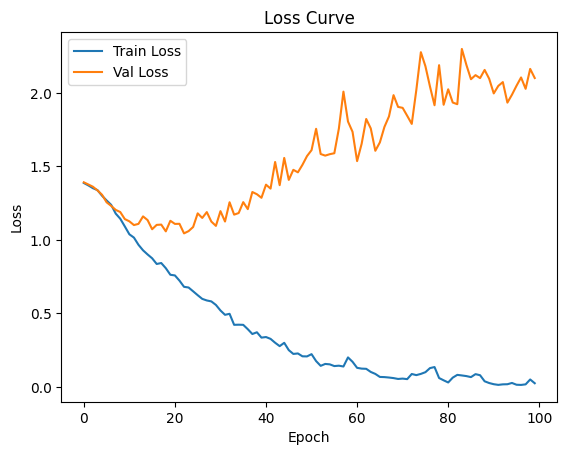

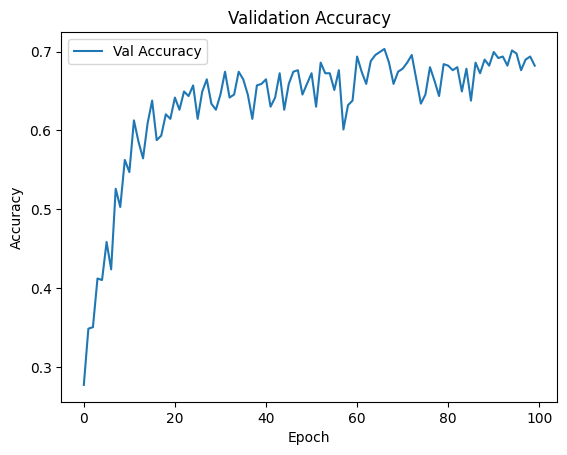

Final Accuracy: 0.6801541425818882
              precision    recall  f1-score   support

           0       0.73      0.74      0.74       130
           1       0.70      0.80      0.74       129
           2       0.55      0.67      0.61       130
           3       0.81      0.52      0.63       130

    accuracy                           0.68       519
   macro avg       0.70      0.68      0.68       519
weighted avg       0.70      0.68      0.68       519



In [146]:
history = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=100,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

plot_history(history)
final_evaluation(model, val_loader)

# SAMPLE CLASSIFICATION MODEL 

In [8]:
import torch.nn as nn

class CNN_LSTM(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        # CNN
        self.conv1 = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.Dropout(0.3)
        )

        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.Dropout(0.3)
        )

        # LSTM
        self.lstm1 = nn.LSTM(128, 200, batch_first=True)
        self.lstm2 = nn.LSTM(200, 100, batch_first=True)

        # FC
        self.fc = nn.Linear(100, n_classes)

    def forward(self, x):
        # x: (B, T, C) → (B, C, T)
        x = x.permute(0, 2, 1)

        x = self.conv1(x)
        x = self.conv2(x)

        # back to (B, T, C)
        x = x.permute(0, 2, 1)

        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)

        x = x[:, -1, :]  # last timestep

        return self.fc(x)

In [100]:
model = CNN_LSTM(n_channels=X_train.shape[2], n_classes=4)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
history = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=500,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

plot_history(history)
final_evaluation(model, val_loader)

# ATTENTION BASED 

In [62]:
import torch
import torch.nn as nn

class CNNTransformer(nn.Module):
    def __init__(self, n_channels=25, n_classes=4):
        super().__init__()

        # CNN Feature Extractor
        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=3, padding=1),
            nn.GELU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.GELU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2)
        )

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            dim_feedforward=256,
            dropout=0.3,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # Classification
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # x: (N, T, C)
        x = x.permute(0, 2, 1)  # (N, C, T)

        x = self.cnn(x)  # (N, 128, T')

        x = x.permute(0, 2, 1)  # (N, T', 128)

        x = self.transformer(x)  # (N, T', 128)

        x = x.mean(dim=1)  # Global average pooling

        x = self.fc(x)

        return x

In [ ]:
from tqdm import trange
device = 'cuda' if torch.cuda.is_available() else 'cpu'


lr = 1e-4
batch_size = 32
epochs = 40

In [ ]:
model = CNNTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)
criterion = nn.CrossEntropyLoss()

C:\Users\Madhav\AppData\Local\Temp\ipykernel_19352\2717855529.py:8: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [82]:
train_loss_history = []
val_acc_history = []

for epoch in trange(20, desc="Training Epochs"):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    
    train_loss_history.append(train_loss / len(train_loader.dataset))

    # validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
        val_acc = correct / total

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Acc={val_acc:.4f}")

Training Epochs:   5%|▌         | 1/20 [00:10<03:20, 10.55s/it]

Epoch 1: Train Loss=3137.4466, Val Acc=0.2494


Training Epochs:  10%|█         | 2/20 [00:20<03:01, 10.09s/it]

Epoch 2: Train Loss=3072.6013, Val Acc=0.2725


Training Epochs:  15%|█▌        | 3/20 [00:30<02:49,  9.94s/it]

...

Epoch 18: Train Loss=2988.2463, Val Acc=0.3650


Training Epochs:  95%|█████████▌| 19/20 [06:08<00:28, 28.28s/it]

Epoch 19: Train Loss=2982.0783, Val Acc=0.3393


Training Epochs: 100%|██████████| 20/20 [06:37<00:00, 19.90s/it]

Epoch 20: Train Loss=2985.5283, Val Acc=0.3599


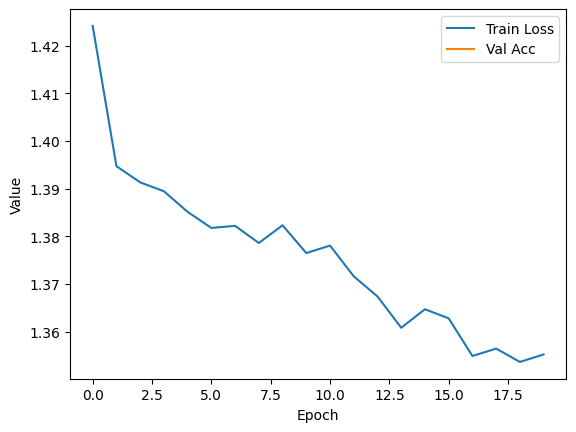

In [83]:
import matplotlib.pyplot as plt

plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_acc_history, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()

# TRAINING PER SUBJECT 

In [122]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
BATCH_SIZE = 64
EPOCHS = 50

In [154]:
import math
import torch.nn.functional as F

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)
    
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(channels)
        )

    def forward(self, x):
        return F.relu(x + self.block(x))

class EEGModel(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        self.spatial = nn.Sequential(
            nn.Conv1d(n_channels, n_channels, kernel_size=1, groups=n_channels),  # depthwise
            nn.Conv1d(n_channels, 128, kernel_size=1),  # pointwise
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        # Pos Encoding
        self.pos_enc = PositionalEncoding(128)

        # Temporal CNN
        self.cnn = nn.Sequential(
            ResidualBlock(128),
            nn.MaxPool1d(2),
            ResidualBlock(128),
            nn.MaxPool1d(2),
        )

        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=8,
            dim_feedforward=256,
            dropout=0.3,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

        self.attn_pool = nn.Sequential(
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)   # (N, C, T)

        x = self.spatial(x)
        x = self.cnn(x)

        x = x.permute(0, 2, 1)   # (N, T, F)
        x = self.pos_enc(x)
        x = self.transformer(x)

        weights = torch.softmax(self.attn_pool(x), dim=1)
        x = (x * weights).sum(dim=1)
        return self.fc(x)

Used Annotations descriptions: [np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
0 bad epochs dropped



Epoch 1/50
Train Loss: 1.4124
Val Loss: 1.3993 | Val Acc: 0.2414



Epoch 2/50
Train Loss: 1.3882
Val Loss: 1.3919 | Val Acc: 0.2414



Epoch 3/50
Train Loss: 1.3772
Val Loss: 1.3910 | Val Acc: 0.2414



Epoch 4/50
Train Loss: 1.3534
Val Loss: 1.3941 | Val Acc: 0.2414


...


Epoch 46/50
Train Loss: 0.8906
Val Loss: 1.1875 | Val Acc: 0.4828



Epoch 47/50
Train Loss: 0.8932
Val Loss: 1.1881 | Val Acc: 0.4828



Epoch 48/50
Train Loss: 0.8941
Val Loss: 1.1886 | Val Acc: 0.4828



Epoch 49/50
Train Loss: 0.8864
Val Loss: 1.1883 | Val Acc: 0.4828



Epoch 50/50
Train Loss: 0.8889
Val Loss: 1.1881 | Val Acc: 0.4828


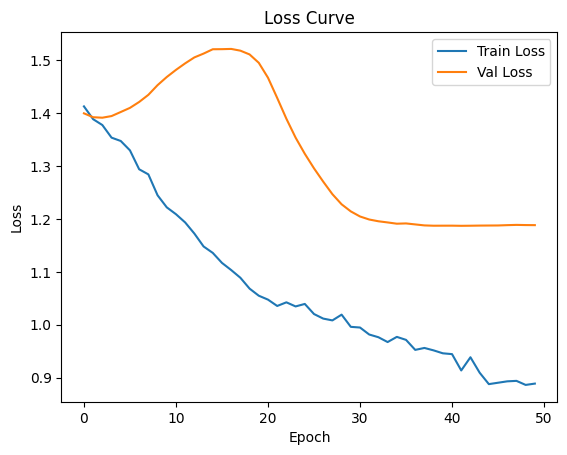

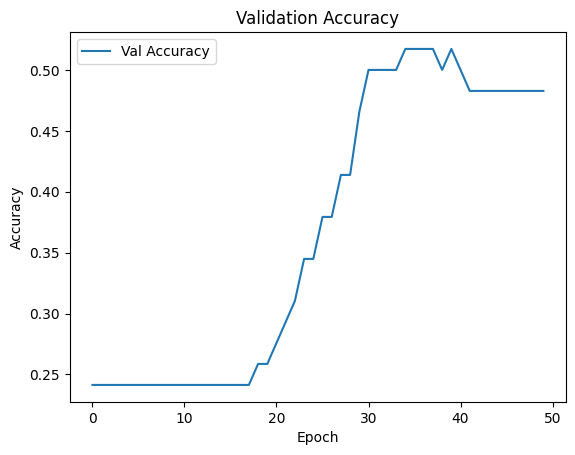

Final Accuracy: 0.4827586206896552
              precision    recall  f1-score   support

           0       0.38      0.33      0.36        15
           1       0.45      0.64      0.53        14
           2       0.50      0.20      0.29        15
           3       0.58      0.79      0.67        14

    accuracy                           0.48        58
   macro avg       0.48      0.49      0.46        58
weighted avg       0.48      0.48      0.45        58



In [155]:
for raw in training_bci:
    X_raw, y_raw = preprocess_raw(raw, event_id=BCI_Label_Mappings)

    X = np.array(X_raw)
    y = np.array(y_raw)

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    mean = X_train.mean(axis=(0,2), keepdims=True)
    std  = X_train.std(axis=(0,2), keepdims=True)

    X_train = (X_train - mean) / std
    X_val   = (X_val - mean) / std

    X_train = np.transpose(X_train, (0, 2, 1))  # (N, T, C)
    X_val   = np.transpose(X_val, (0, 2, 1))

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = EEGModel(n_channels=X_train.shape[2], n_classes=4)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5
    )

    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    #     optimizer,
    #     T_max=EPOCHS,     
    #     eta_min=1e-5 
    # )

    history = train(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,        
    
        scheduler = scheduler,
        epochs=EPOCHS,
        device="cuda" if torch.cuda.is_available() else "cpu"
    )

    plot_history(history)
    final_evaluation(model, val_loader, device="cuda" if torch.cuda.is_available() else "cpu")

    break 